# Creating Initial Conditions for the Elkhorn Slough MITgcm Model

This notebook creates the initial temperature, salinity, and dissolved oxygen fields for the Elkhorn Slough model. Station observations are interpolated onto the model grid and then written as MITgcm binary files.

The final files generated by this notebook are:

- `THETA_IC.bin`
- `SALT_IC.bin`
- `DO_IC.bin`

Each file has shape `(Nr, Ny, Nx) = (5, 240, 360)` and is written as big-endian 32-bit floats.

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.spatial import cKDTree

Next, define the location of the input directory for the model. This is the same directory that holds the bathymetry file generated in the previous notebooks for this model example.

In [31]:
# File paths

# Folder where model input files are stored
input_dir = r"C:\Users\rilee\MS 274\Final_Project\input"

# Station data file
station_file = "station_file.csv"

print("Input directory:", input_dir)
print("Bathymetry file:", os.path.join(input_dir, "slough_bathymetry.bin"))

Input directory: C:\Users\rilee\MS 274\Final_Project\input
Bathymetry file: C:\Users\rilee\MS 274\Final_Project\input\slough_bathymetry.bin


## Constructing the Initial Conditions

The initial condition fields are created from NERRS (National Estuarine Research Reserve System) station observations. The workflow is:

1. Load station metadata and water-quality observations.
2. Recreate the model grid.
3. Read the final cleaned MITgcm bathymetry.
4. Build a wet/dry mask from the bathymetry.
5. Compute station means for the initialization month.
6. Interpolate temperature, salinity, and dissolved oxygen onto the wet model cells.
7. Repeat each 2-D surface field vertically across the five model layers.
8. Save the resulting 3-D fields as MITgcm binary files.
9. Plot the fields to check that they look reasonable.

Because only surface station observations are used here, the initial fields are assumed to be vertically uniform.

### Step 1: Download the NERRS fields
To begin, I downloaded the water quality and weather data from NERRS. These fields are available [HERE](https://cdmo.baruch.sc.edu/aqs/chooseYearsCustomWaterMet.cfm). In particular, I downloaded the following list of files that contain the field pertaining to starting point of my model (September 2025):

I stored these fields in the same directory as this notebook:

In [32]:
# Load station observations and metadata

stations = pd.read_csv(station_file)

# Station longitude/latitude metadata
# These coordinates are used for interpolation onto the model grid.
station_meta = pd.DataFrame({
    "StationCode": ["elkcwmet", "elkapwq", "elknmwq", "elksmwq", "elkvmwq"],
    "lon": [-121.738, -121.754, -121.738, -121.739, -121.779],
    "lat": [ 36.815,   36.846,   36.835,   36.818,   36.811],
})

print("Station data shape:", stations.shape)
station_meta

Station data shape: (14494, 7)


,StationCode,lon,lat
0,elkcwmet,-121.738,36.815
1,elkapwq,-121.754,36.846
2,elknmwq,-121.738,36.835
3,elksmwq,-121.739,36.818
4,elkvmwq,-121.779,36.811


### Step 3: Read in the Model Grid and Generate a Mask
Here, I will recreate the grid I will use in my model and read in the bathymetry file (see previous notebooks for details):

In [33]:
# Recreate model grid

xgOrigin = -121.795
ygOrigin = 36.8

Nx = 360
Ny = 240
Nr = 5

delX = 0.0001555555555555483
delY = 0.00025416666666666643

rxc = xgOrigin + (np.arange(Nx) + 0.5) * delX
ryc = ygOrigin + (np.arange(Ny) + 0.5) * delY

XC, YC = np.meshgrid(rxc, ryc)

# Read final MITgcm bathymetry

bathy_file = os.path.join(input_dir, "slough_bathymetry.bin")

bathy = np.fromfile(bathy_file, dtype=">f4").reshape((Ny, Nx))


XC shape: (240, 360)
YC shape: (240, 360)
bathy shape: (240, 360)
NaN count: 0
min/max: -29.71549 0.0
wet cells: 6399
land cells: 80001


With an eye toward the interpolation to come next, I will make a mask to determine where the interpolatation will take place. 

In [34]:
# Create depth and wet masks

bathy_pd = np.where(bathy < 0, -bathy, 0.0)

# Vertical grid used in MITgcm
delR = np.array([1, 2, 3, 4, 5], dtype=float)
Nr = len(delR)

print("delR:", delR)
print("Nr:", Nr)
print("Total model depth:", delR.sum(), "m")

# Surface/wet mask:
# 1 = water
# 0 = land
mask2d = (bathy_pd > 0).astype(np.int8)

print("mask2d shape:", mask2d.shape)
print("wet cells:", np.sum(mask2d == 1))
print("land cells:", np.sum(mask2d == 0))

delR: [1. 2. 3. 4. 5.]
Nr: 5
Total model depth: 15.0 m
mask2d shape: (240, 360)
wet cells: 6399
land cells: 80001


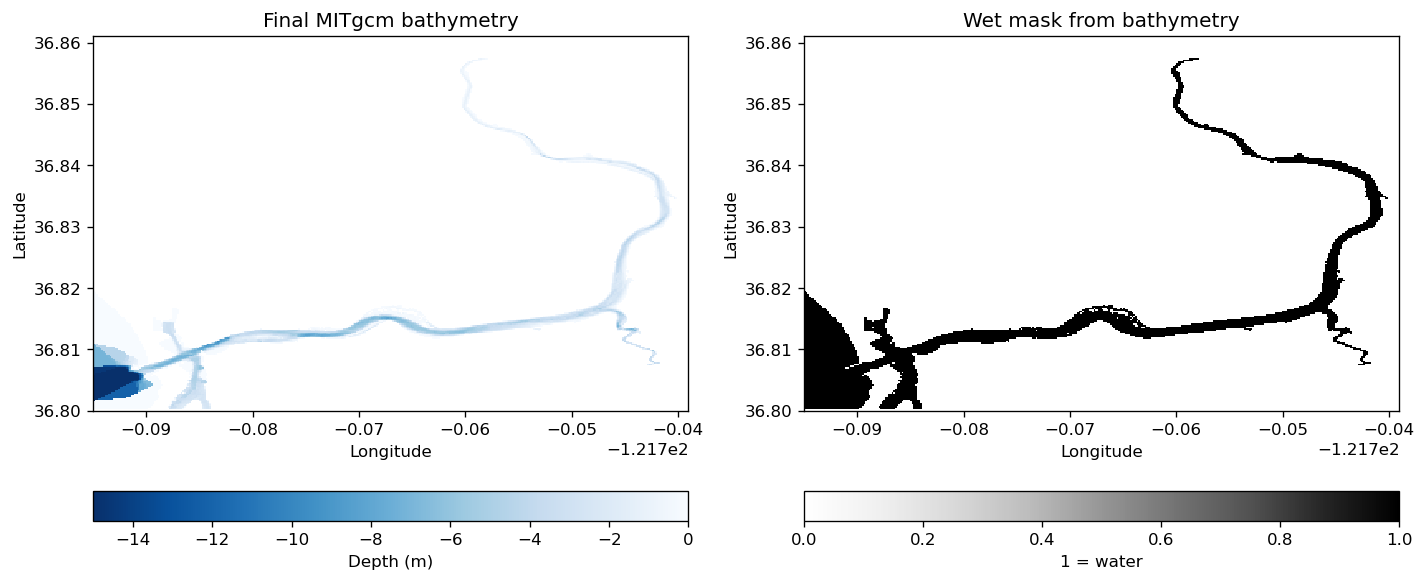

In [35]:
# Plot bathymetry and wet mask

bathy_plot = np.ma.masked_where(bathy == 0, bathy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

cmap_bathy = plt.get_cmap("Blues_r").copy()
cmap_bathy.set_bad("white")

im0 = axes[0].pcolormesh(
    XC, YC, bathy_plot,
    shading="auto",
    cmap=cmap_bathy,
    vmin=-15,
    vmax=0
)
fig.colorbar(im0, ax=axes[0], orientation="horizontal", label="Depth (m)")
axes[0].set_title("Final MITgcm bathymetry")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

im1 = axes[1].pcolormesh(
    XC, YC, mask2d,
    shading="auto",
    cmap="Greys",
    vmin=0,
    vmax=1
)
fig.colorbar(im1, ax=axes[1], orientation="horizontal", label="1 = water")
axes[1].set_title("Wet mask from bathymetry")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

### Step 4: Interpolate the Fields onto the Model Grid
Next, I will interpolate the NERRS external fields I read in onto my model domain. I will use the `horizonal` module from the `eccoseas` package to accomplish this interpolation.

In [36]:
# Attach station coordinates to observations

def norm_key(s):
    """Normalize station names so matching is case/spacing insensitive."""
    return str(s).strip().casefold()

# Build lookup dictionaries
lon_map = dict(zip(station_meta["StationCode"].map(norm_key), station_meta["lon"]))
lat_map = dict(zip(station_meta["StationCode"].map(norm_key), station_meta["lat"]))

# Normalize station codes in the observation table
stations = stations.copy()
stations["__key"] = stations["StationCode"].map(norm_key)

# Add lon/lat to each observation
stations["lon"] = stations["__key"].map(lon_map)
stations["lat"] = stations["__key"].map(lat_map)

# Check for station codes that did not match metadata
missing = stations.loc[
    stations["lon"].isna() | stations["lat"].isna(),
    "StationCode"
].dropna().unique()

print("Missing coordinate matches:", list(missing))

Missing coordinate matches: []


In [37]:
# Select initialization month and compute station means

stations["DateTimeStamp"] = pd.to_datetime(stations["DateTimeStamp"], errors="coerce")

# Rename dissolved oxygen column if needed
if "DO_mgl" in stations.columns and "DO" not in stations.columns:
    stations = stations.rename(columns={"DO_mgl": "DO"})

# Initialization month
start_date = "2024-10-01"
end_date   = "2024-10-31"

month_mask = (
    (stations["DateTimeStamp"] >= start_date)
    & (stations["DateTimeStamp"] <= end_date)
)

month_df = stations.loc[
    month_mask,
    ["StationCode", "lon", "lat", "Temp", "Sal", "DO"]
].copy()

# Convert columns to numeric
for c in ["lon", "lat", "Temp", "Sal", "DO"]:
    month_df[c] = pd.to_numeric(month_df[c], errors="coerce")

# Average each variable at each station
station_mean = (
    month_df
    .groupby("StationCode")[["lon", "lat", "Temp", "Sal", "DO"]]
    .mean()
    .reset_index()
)

print("Number of stations used:", len(station_mean))
station_mean

Number of stations used: 5


,StationCode,lon,lat,Temp,Sal,DO
0,elkapwq,-121.754,36.846,17.740125,34.190975,1.127838
1,elkcwmet,-121.738,36.815,NaN,NaN,NaN
2,elknmwq,-121.738,36.835,19.027733,33.996355,7.205241
3,elksmwq,-121.739,36.818,17.911697,32.822215,7.651683
4,elkvmwq,-121.779,36.811,14.992989,32.629261,7.357341


In [38]:
# Interpolation helper functions

def lonlat_to_local_m(lon, lat, lon0, lat0):
    """
    Convert longitude/latitude in degrees to local x/y coordinates in meters.

    This simple equirectangular approximation is appropriate for a small domain
    like Elkhorn Slough.
    """
    R = 6371000.0

    lon = np.asarray(lon)
    lat = np.asarray(lat)

    lam = np.radians(lon)
    phi = np.radians(lat)
    lam0 = np.radians(lon0)
    phi0 = np.radians(lat0)

    x = R * (lam - lam0) * np.cos(phi0)
    y = R * (phi - phi0)

    return x, y


def interpolate_idw_to_grid_meters(df, var, XC, YC, mask2d, k=4, power=2):
    """
    Interpolate station data to the model grid using inverse-distance weighting.

    Parameters
    ----------
    df : DataFrame
        Station means with columns lon, lat, and the variable to interpolate.
    var : str
        Variable name to interpolate.
    XC, YC : 2D arrays
        Model longitude and latitude arrays.
    mask2d : 2D array
        1 for water cells, 0 for land cells.
    k : int
        Number of nearest stations used for interpolation.
    power : float
        Distance weighting power.

    Returns
    -------
    out : 2D array
        Interpolated field on the model grid. Land cells are NaN.
    """

    valid = df[np.isfinite(df[var])].copy()

    if valid.empty:
        raise ValueError(f"No valid station values found for {var}")

    if XC.shape != YC.shape or XC.shape != mask2d.shape:
        raise ValueError(
            f"XC, YC, and mask2d must have same shape. "
            f"Got {XC.shape}, {YC.shape}, {mask2d.shape}"
        )

    lon0 = valid["lon"].mean()
    lat0 = valid["lat"].mean()

    xs, ys = lonlat_to_local_m(
        valid["lon"].to_numpy(),
        valid["lat"].to_numpy(),
        lon0,
        lat0
    )
    values = valid[var].to_numpy()

    xg, yg = lonlat_to_local_m(XC, YC, lon0, lat0)

    out = np.full(XC.shape, np.nan, dtype=float)

    # Only interpolate water cells
    j_wet, i_wet = np.where(mask2d == 1)

    target_points = np.column_stack([xg[j_wet, i_wet], yg[j_wet, i_wet]])
    station_points = np.column_stack([xs, ys])

    tree = cKDTree(station_points)
    distances, indices = tree.query(target_points, k=min(k, len(valid)))

    # Ensure 2D shape when only one neighbor is returned
    if distances.ndim == 1:
        distances = distances[:, np.newaxis]
        indices = indices[:, np.newaxis]

    weights = 1.0 / np.maximum(distances, 1e-12) ** power
    interpolated_values = np.sum(weights * values[indices], axis=1) / np.sum(weights, axis=1)

    out[j_wet, i_wet] = interpolated_values

    return out

In [39]:
# Interpolate station means onto model grid

variables = ["Temp", "Sal", "DO"]
interpolated = {}

for var in variables:
    interpolated[var] = interpolate_idw_to_grid_meters(
        station_mean,
        var,
        XC,
        YC,
        mask2d,
        k=4,
        power=2
    )

    print(
        var,
        "shape:", interpolated[var].shape,
        "NaNs:", np.isnan(interpolated[var]).sum(),
        "min:", np.nanmin(interpolated[var]),
        "max:", np.nanmax(interpolated[var])
    )

Temp shape: (240, 360) NaNs: 80001 min: 14.993665963233507 max: 18.992121359035266
Sal shape: (240, 360) NaNs: 80001 min: 32.629455883096675 max: 34.18844683831827
DO shape: (240, 360) NaNs: 80001 min: 1.1534610258875142 max: 7.450159866030658


In [40]:
# -----------------------------
# Create 3-D MITgcm IC files and save
# -----------------------------

file_dict = {
    "Temp": "THETA_IC.bin",
    "Sal":  "SALT_IC.bin",
    "DO":   "DO_IC.bin",
}

for var in variables:
    grid2d = interpolated[var]

    # Repeat the 2D field vertically through all model layers.
    # This assumes vertically uniform initial conditions.
    grid3d = np.tile(grid2d[np.newaxis, :, :], (Nr, 1, 1))

    # MITgcm should not receive NaNs.
    # Land cells are set to 0.
    grid3d = np.where(np.isfinite(grid3d), grid3d, 0.0).astype(np.float32)

    output_file = os.path.join(input_dir, file_dict[var])

    grid3d.ravel(order="C").astype(">f4").tofile(output_file)

    print(
        "Wrote:", output_file,
        "shape:", grid3d.shape,
        "NaNs:", np.isnan(grid3d).sum(),
        "min:", np.nanmin(grid3d),
        "max:", np.nanmax(grid3d)
    )

Wrote: C:\Users\rilee\MS 274\Final_Project\input\THETA_IC.bin shape: (5, 240, 360) NaNs: 0 min: 0.0 max: 18.99212
Wrote: C:\Users\rilee\MS 274\Final_Project\input\SALT_IC.bin shape: (5, 240, 360) NaNs: 0 min: 0.0 max: 34.188446
Wrote: C:\Users\rilee\MS 274\Final_Project\input\DO_IC.bin shape: (5, 240, 360) NaNs: 0 min: 0.0 max: 7.45016


### Step 6: Plotting the Initial Condition Fields
Now that the fields have been generated, I will plot them to ensure they look as expected. First, I'll generate some metadata for each one:

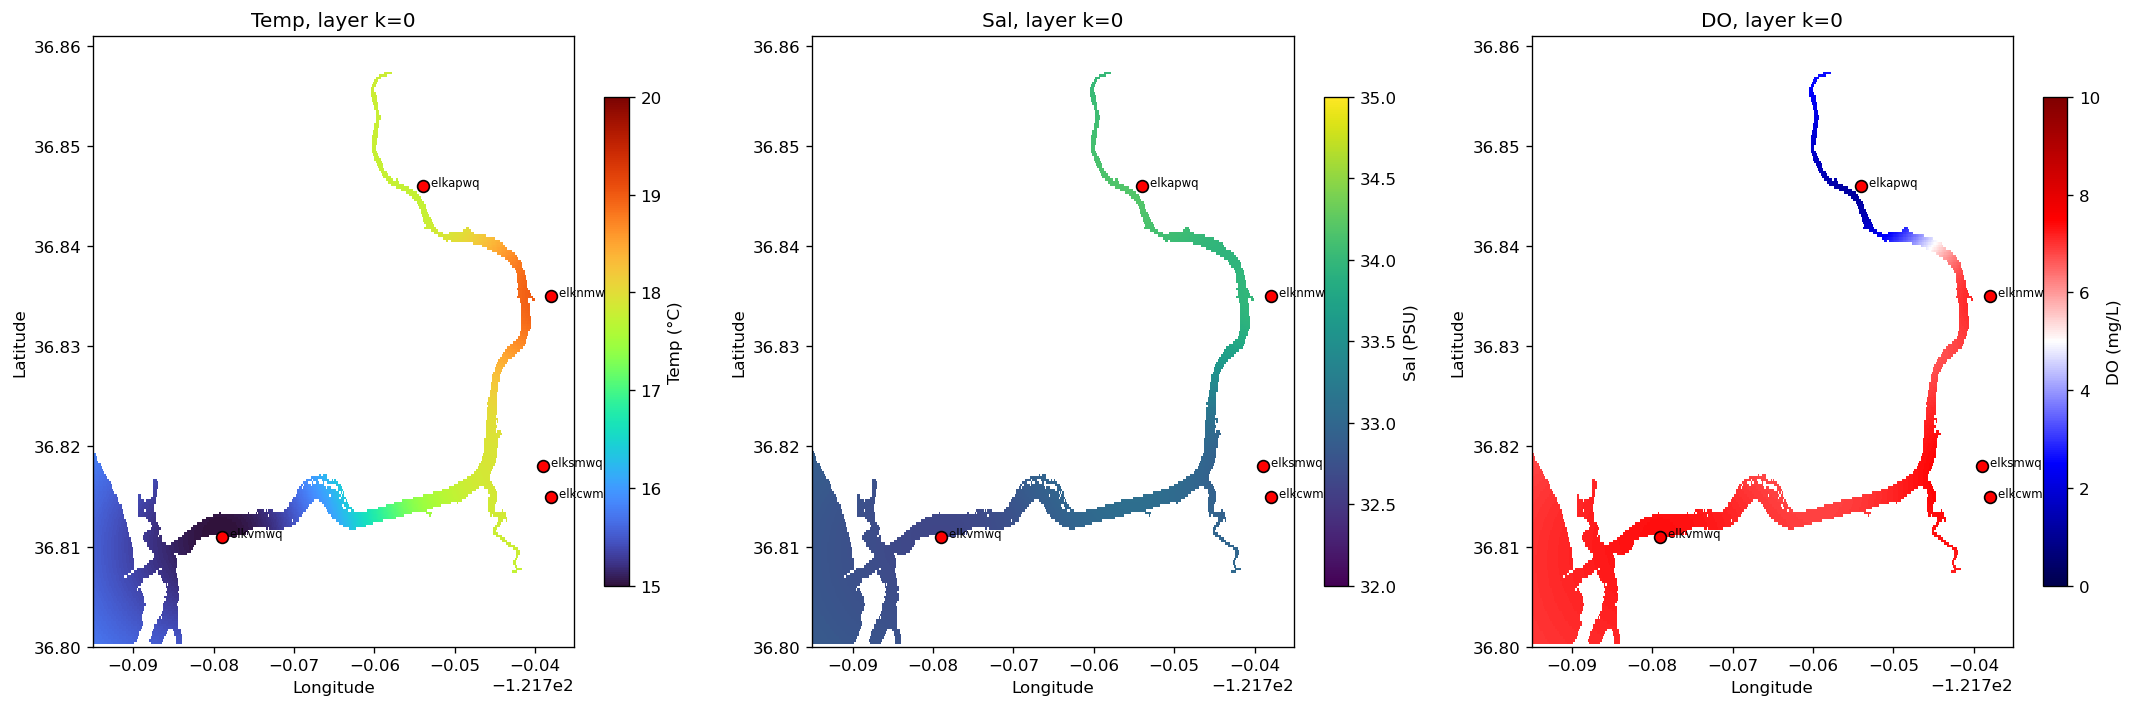

In [41]:
# -----------------------------
# Plot final initial condition fields
# -----------------------------

variable_names = ["Temp", "Sal", "DO"]

file_dict = {
    "Temp": "THETA_IC.bin",
    "Sal":  "SALT_IC.bin",
    "DO":   "DO_IC.bin",
}

meta_dict = {
    "Temp": (15, 20, "turbo", "°C"),
    "Sal":  (32, 35, "viridis", "PSU"),
    "DO":   (0, 10, "seismic", "mg/L"),
}

k = 0  # surface layer

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=120)

for ax, var in zip(axes, variable_names):
    path = os.path.join(input_dir, file_dict[var])

    arr = np.fromfile(path, dtype=">f4")
    expected_size = Nr * Ny * Nx

    if arr.size != expected_size:
        raise ValueError(
            f"{file_dict[var]} size {arr.size} does not match expected {expected_size}"
        )

    grid3d = arr.reshape((Nr, Ny, Nx), order="C")
    grid2d = grid3d[k]

    # Mask land cells for plotting
    plot_field = np.ma.masked_where(mask2d == 0, grid2d)

    vmin, vmax, cmap_name, units = meta_dict[var]
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("white")

    im = ax.pcolormesh(
        XC,
        YC,
        plot_field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(
        station_mean["lon"],
        station_mean["lat"],
        c="red",
        edgecolors="black",
        s=50,
        zorder=3
    )

    for _, row in station_mean.iterrows():
        ax.text(
            row["lon"] + 0.001,
            row["lat"],
            row["StationCode"],
            fontsize=7,
            color="black"
        )

    fig.colorbar(im, ax=ax, shrink=0.8, label=f"{var} ({units})")
    ax.set_title(f"{var}, layer k={k}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [42]:
# -----------------------------
# Check that all vertical layers are identical
# -----------------------------

for var in variable_names:
    path = os.path.join(input_dir, file_dict[var])
    grid3d = np.fromfile(path, dtype=">f4").reshape((Nr, Ny, Nx))

    print(var)
    for k in range(Nr):
        max_diff = np.nanmax(np.abs(grid3d[k] - grid3d[0]))
        print(f"  layer {k}: max difference from layer 0 = {max_diff}")

Temp
  layer 0: max difference from layer 0 = 0.0
  layer 1: max difference from layer 0 = 0.0
  layer 2: max difference from layer 0 = 0.0
  layer 3: max difference from layer 0 = 0.0
  layer 4: max difference from layer 0 = 0.0
Sal
  layer 0: max difference from layer 0 = 0.0
  layer 1: max difference from layer 0 = 0.0
  layer 2: max difference from layer 0 = 0.0
  layer 3: max difference from layer 0 = 0.0
  layer 4: max difference from layer 0 = 0.0
DO
  layer 0: max difference from layer 0 = 0.0
  layer 1: max difference from layer 0 = 0.0
  layer 2: max difference from layer 0 = 0.0
  layer 3: max difference from layer 0 = 0.0
  layer 4: max difference from layer 0 = 0.0


### Step 7: Run-time considerations
## Run-time considerations

The temperature and salinity initial condition files are used in the MITgcm `data` namelist through:

```fortran
hydrogThetaFile = 'THETA_IC.bin',
hydrogSaltFile  = 'SALT_IC.bin',